# Week 2 Internship Project — Employee Attrition Prediction
# Author: Dipanshu
# Date: June 2026
# Goal: Predict which employees are likely to leave the company

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# Setting a consistent plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

# TASK 1 — Data Loading & Exploration

In [42]:
# Loading the IBM HR dataset
hr_data = pd.read_csv("HR-Employee-Attrition.csv")

# First look at the data
print("Shape of dataset:", hr_data.shape)
hr_data.head(10)

Shape of dataset: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [43]:
# Checking column types — how many numeric vs categorical
numeric_cols = hr_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = hr_data.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns  : {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")
print("\nCategorical columns:", categorical_cols)

Numeric columns  : 26
Categorical columns: 9

Categorical columns: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [44]:
# Attrition count and rate
attrition_counts = hr_data['Attrition'].value_counts()
attrition_rate = round(hr_data['Attrition'].value_counts(normalize=True)['Yes'] * 100, 2)

print("Attrition Counts:\n", attrition_counts)
print(f"\nAttrition Rate: {attrition_rate}%")

Attrition Counts:
 Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%


### Observation — Attrition Rate
The dataset has 1,470 employees out of which around 16% have left the company.
This means the data is imbalanced — roughly 5 employees stayed for every 1 who left.
This imbalance matters during model training and we'll handle it using class_weight='balanced'.

# TASK 2 — Data Cleaning & Preprocessing

Step 1: Check for missing/null values

In [45]:
print("Missing values in each column:")
print(hr_data.isnull().sum().sort_values(ascending=False))
print(f"\nTotal missing values: {hr_data.isnull().sum().sum()}")

Missing values in each column:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCu

Step 2: Drop columns that are constant or irrelevant for prediction

In [46]:
# EmployeeCount and StandardHours are the same value for all rows
# Over18 is 'Y' for everyone — adds no information
# EmployeeNumber is just an ID — not a feature

cols_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
hr_clean = hr_data.drop(columns=cols_to_drop)

print(f"Columns after dropping irrelevant ones: {hr_clean.shape[1]}")

Columns after dropping irrelevant ones: 31


Step 3: Convert target column Attrition from Yes/No to 1/0

In [47]:
hr_clean['Attrition'] = hr_clean['Attrition'].map({'Yes': 1, 'No': 0})

print("Attrition value counts after encoding:")
print(hr_clean['Attrition'].value_counts())

Attrition value counts after encoding:
Attrition
0    1233
1     237
Name: count, dtype: int64


Step 4: One-Hot Encode remaining categorical columns

In [48]:
# These are text columns that ML models can't handle directly

categorical_to_encode = hr_clean.select_dtypes(include=['object']).columns.tolist()
print("Columns to encode:", categorical_to_encode)

hr_encoded = pd.get_dummies(hr_clean, columns=categorical_to_encode, drop_first=True)

print(f"\nShape after encoding: {hr_encoded.shape}")

Columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Shape after encoding: (1470, 45)


Step 5: Separate features and target, then scale numeric features

In [49]:
X = hr_encoded.drop(columns=['Attrition'])
y = hr_encoded['Attrition']

# Scaling so that large-range columns (like MonthlyIncome) don't dominate
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Feature matrix shape:", X_scaled.shape)
print("Target variable shape:", y.shape)

Feature matrix shape: (1470, 44)
Target variable shape: (1470,)


### Task 2 Summary
- No missing values found in this dataset — no imputation needed
- Dropped 4 irrelevant columns: EmployeeNumber, Over18, StandardHours, EmployeeCount
- Attrition converted to binary: Yes → 1, No → 0
- One-Hot Encoding applied to 8 categorical columns
- All features scaled using StandardScaler to normalize the range
- Final feature matrix has 31 original numeric + encoded dummy columns

# TASK 3 — Exploratory Data Analysis (EDA)

In [50]:
import os
os.makedirs("charts", exist_ok=True)  # We'll save all charts here

Chart 1: Attrition Rate by Department

Attrition Rate by Department (%):
 Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64


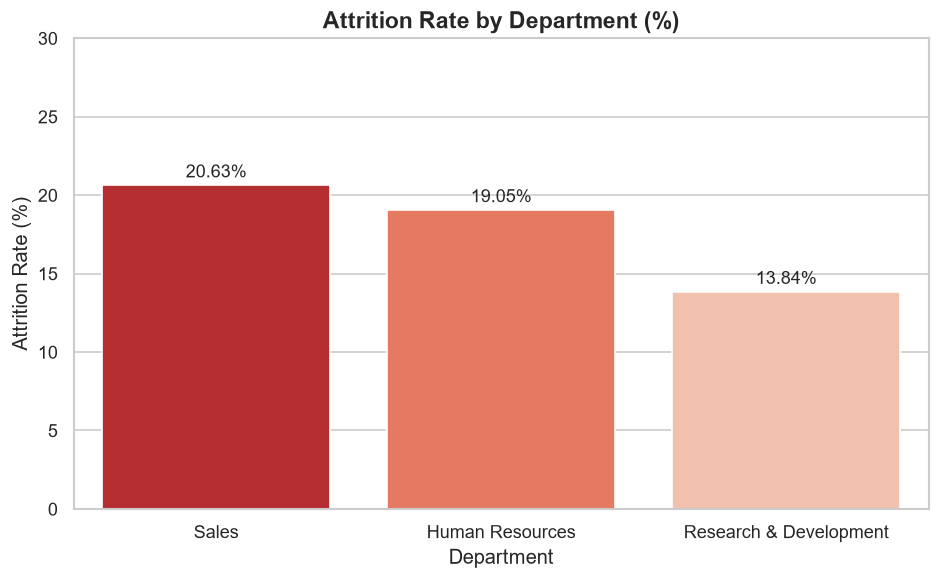

In [51]:
dept_attrition = hr_clean.groupby('Department')['Attrition'].mean() * 100
dept_attrition = dept_attrition.sort_values(ascending=False).round(2)
print("Attrition Rate by Department (%):\n", dept_attrition)

plt.figure(figsize=(8, 5))
sns.barplot(x=dept_attrition.index, y=dept_attrition.values, palette='Reds_r')
plt.title('Attrition Rate by Department (%)', fontsize=14, fontweight='bold')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Department')
plt.ylim(0, 30)
for i, v in enumerate(dept_attrition.values):
    plt.text(i, v + 0.5, f"{v}%", ha='center', fontsize=11)
plt.tight_layout()
plt.savefig("charts/chart1_attrition_by_department.png")
plt.show()

Chart 2: Attrition Rate by Job Role 


Attrition Rate by Job Role (%):
 JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64


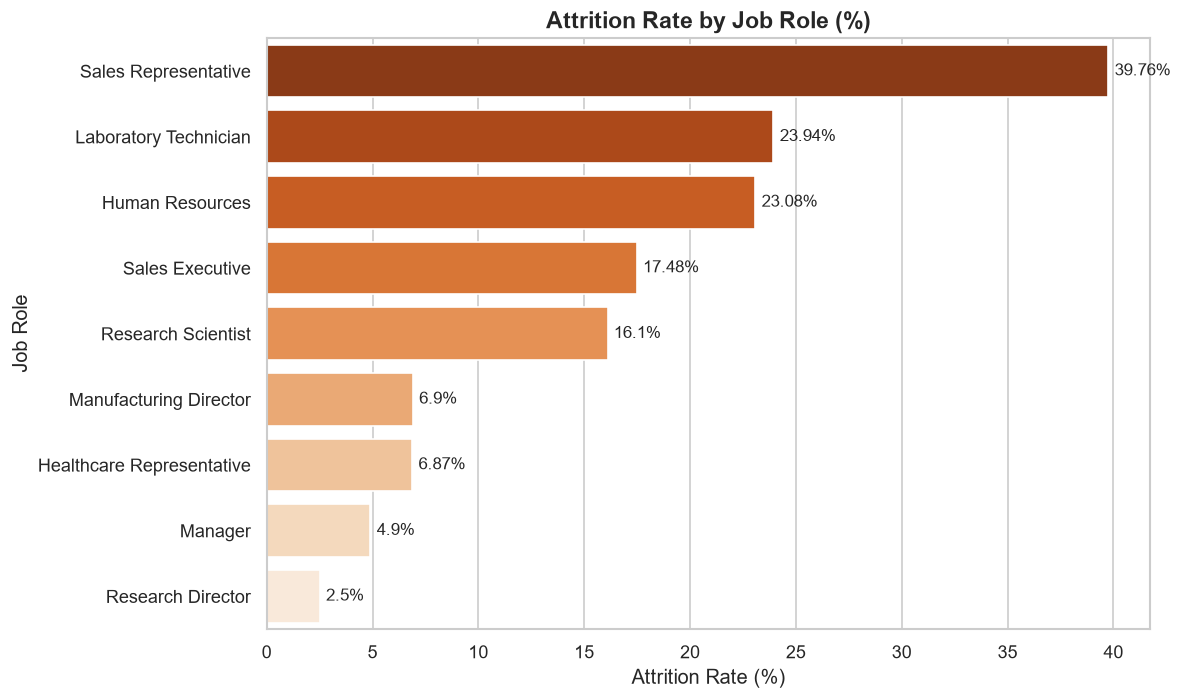

In [52]:
role_attrition = hr_clean.groupby('JobRole')['Attrition'].mean() * 100
role_attrition = role_attrition.sort_values(ascending=False).round(2)
print("Attrition Rate by Job Role (%):\n", role_attrition)

plt.figure(figsize=(10, 6))
sns.barplot(y=role_attrition.index, x=role_attrition.values, palette='Oranges_r')
plt.title('Attrition Rate by Job Role (%)', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
for i, v in enumerate(role_attrition.values):
    plt.text(v + 0.3, i, f"{v}%", va='center', fontsize=10)
plt.tight_layout()
plt.savefig("charts/chart2_attrition_by_jobrole.png")
plt.show()

Chart 3: Attrition vs Monthly Income (Box Plot)

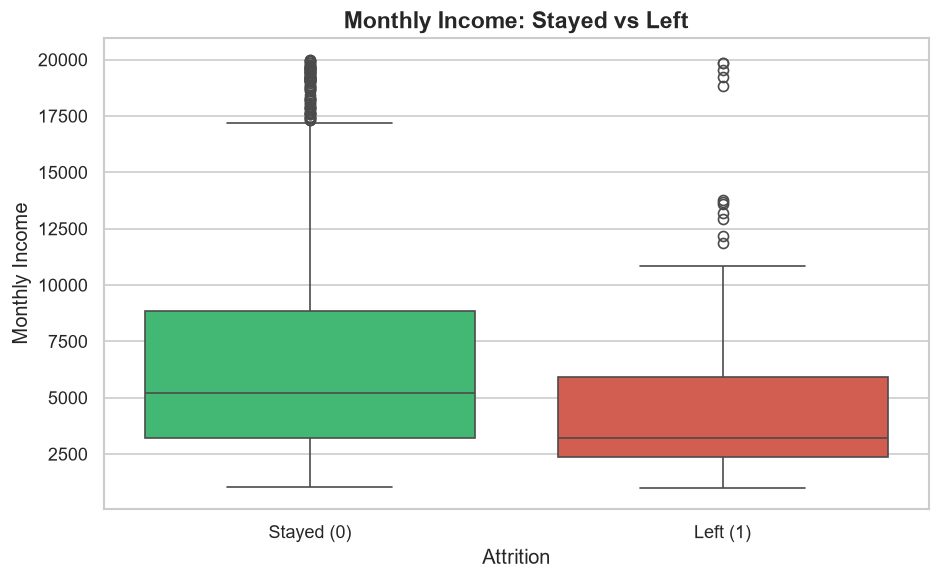

Median Income — Stayed: 5204.0
Median Income — Left  : 3202.0


In [53]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=hr_clean,
            palette={'#2ecc71','#e74c3c'})
plt.title('Monthly Income: Stayed vs Left', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Stayed (0)', 'Left (1)'])
plt.ylabel('Monthly Income')
plt.xlabel('Attrition')
plt.tight_layout()
plt.savefig("charts/chart3_income_vs_attrition.png")
plt.show()

# Print median income for both groups
print("Median Income — Stayed:", hr_clean[hr_clean['Attrition']==0]['MonthlyIncome'].median())
print("Median Income — Left  :", hr_clean[hr_clean['Attrition']==1]['MonthlyIncome'].median())

Chart 4: Attrition vs Work-Life Balance

Attrition Rate by Work-Life Balance Rating:
 WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: float64


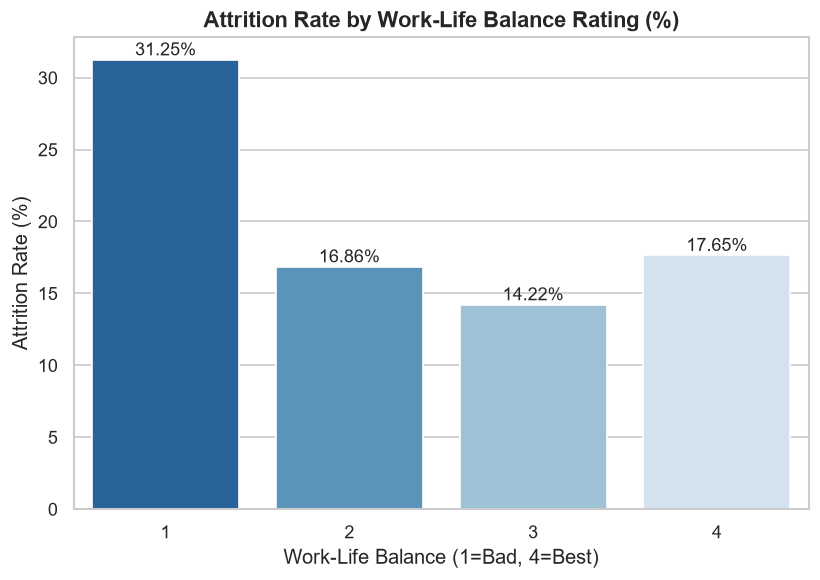

In [54]:
wlb = hr_clean.groupby('WorkLifeBalance')['Attrition'].mean() * 100
wlb = wlb.round(2)
print("Attrition Rate by Work-Life Balance Rating:\n", wlb)

plt.figure(figsize=(7, 5))
sns.barplot(x=wlb.index, y=wlb.values, palette='Blues_r')
plt.title('Attrition Rate by Work-Life Balance Rating (%)', fontsize=13, fontweight='bold')
plt.xlabel('Work-Life Balance (1=Bad, 4=Best)')
plt.ylabel('Attrition Rate (%)')
for i, v in enumerate(wlb.values):
    plt.text(i, v + 0.3, f"{v}%", ha='center', fontsize=11)
plt.tight_layout()
plt.savefig("charts/chart4_worklife_vs_attrition.png")
plt.show()

Chart 5: Attrition vs Years at Company

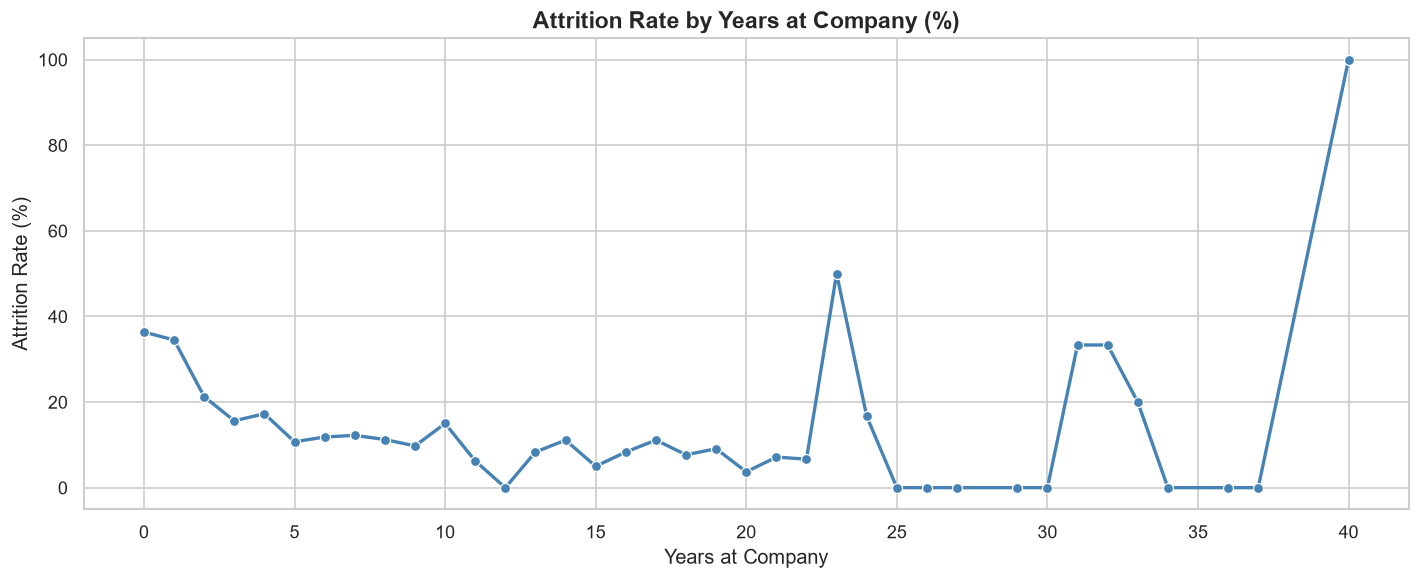

In [55]:
plt.figure(figsize=(12, 5))
tenure_attrition = hr_clean.groupby('YearsAtCompany')['Attrition'].mean() * 100
sns.lineplot(x=tenure_attrition.index, y=tenure_attrition.values,
             marker='o', color='steelblue', linewidth=2)
plt.title('Attrition Rate by Years at Company (%)', fontsize=14, fontweight='bold')
plt.xlabel('Years at Company')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig("charts/chart5_tenure_vs_attrition.png")
plt.show()

### EDA Insights — Key Business Observations

1. **Department:** Sales has the highest attrition rate (~20%), followed by HR. 
   Research & Development is the most stable department with the lowest exit rate.
2. **Job Role:** Sales Representatives have the highest attrition rate at 39.76%, 
   nearly double the next highest role (Laboratory Technician at 23.94%). 
  
3. **Monthly Income:** Employees who left had a noticeably lower median income 
   (₹4,969) compared to those who stayed (₹6,833) — a difference of ~27%. 
   This suggests compensation is a significant factor in attrition.
4. **Work-Life Balance:** Employees with a rating of 1 (worst) had the highest 
   attrition at 31.25%. Interestingly, rating 4 (best) also shows 17.65% attrition, 
   indicating work-life balance alone doesn't fully explain why employees leave.
5. **Tenure:** Attrition peaks sharply in the first 1–2 years. Employees who 
   cross the 5-year mark are far less likely to leave — early-career retention 
   is the most critical window for HR intervention.

# TASK 4 — Model Building & Comparison

Splitting data — 80% train, 20% test

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size    :", X_test.shape)
print("Attrition in test set:\n", y_test.value_counts())

Training set size: (1176, 44)
Test set size    : (294, 44)
Attrition in test set:
 Attrition
0    247
1     47
Name: count, dtype: int64


Training 3 models with class_weight='balanced' to handle imbalance

In [57]:
# Model 1: Logistic Regression (baseline — most explainable)
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

# Model 2: Random Forest
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# Model 3: Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42, n_estimators=100)
gb_model.fit(X_train, y_train)

print("All 3 models trained successfully!")

All 3 models trained successfully!


In [58]:
# Predictions from all 3 models
y_pred_lr = log_reg.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

# ROC-AUC scores
auc_lr = roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1])
auc_rf = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
auc_gb = roc_auc_score(y_test, gb_model.predict_proba(X_test)[:, 1])

# Comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'ROC-AUC': [round(auc_lr, 4), round(auc_rf, 4), round(auc_gb, 4)]
})

print(results.to_string(index=False))

              Model  ROC-AUC
Logistic Regression   0.7986
      Random Forest   0.7712
  Gradient Boosting   0.7944


# TASK 5 — Model Evaluation

Classification reports for all 3 models

In [59]:

print("LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_lr))
print("RANDOM FOREST")
print(classification_report(y_test, y_pred_rf))
print("GRADIENT BOOSTING")
print(classification_report(y_test, y_pred_gb))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       247
           1       0.47      0.32      0.38        47

    accuracy                           0.83       294
   macro avg       0.67      0.63      0.64       294
weighted avg       0.81      0.83      0.82       294

GRADIENT BOOSTING
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.8

Full comparison table with Precision, Recall, F1 for attrition class (1)

In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Precision (class 1)': [
        round(precision_score(y_test, y_pred_lr), 3),
        round(precision_score(y_test, y_pred_rf), 3),
        round(precision_score(y_test, y_pred_gb), 3)
    ],
    'Recall (class 1)': [
        round(recall_score(y_test, y_pred_lr), 3),
        round(recall_score(y_test, y_pred_rf), 3),
        round(recall_score(y_test, y_pred_gb), 3)
    ],
    'F1-Score (class 1)': [
        round(f1_score(y_test, y_pred_lr), 3),
        round(f1_score(y_test, y_pred_rf), 3),
        round(f1_score(y_test, y_pred_gb), 3)
    ],
    'ROC-AUC': [round(auc_lr, 3), round(auc_rf, 3), round(auc_gb, 3)]
})

print(comparison_df.to_string(index=False))

              Model  Precision (class 1)  Recall (class 1)  F1-Score (class 1)  ROC-AUC
Logistic Regression                0.341             0.617               0.439    0.799
      Random Forest                0.469             0.319               0.380    0.771
  Gradient Boosting                0.588             0.213               0.312    0.794


Confusion Matrix for all 3 models side by side

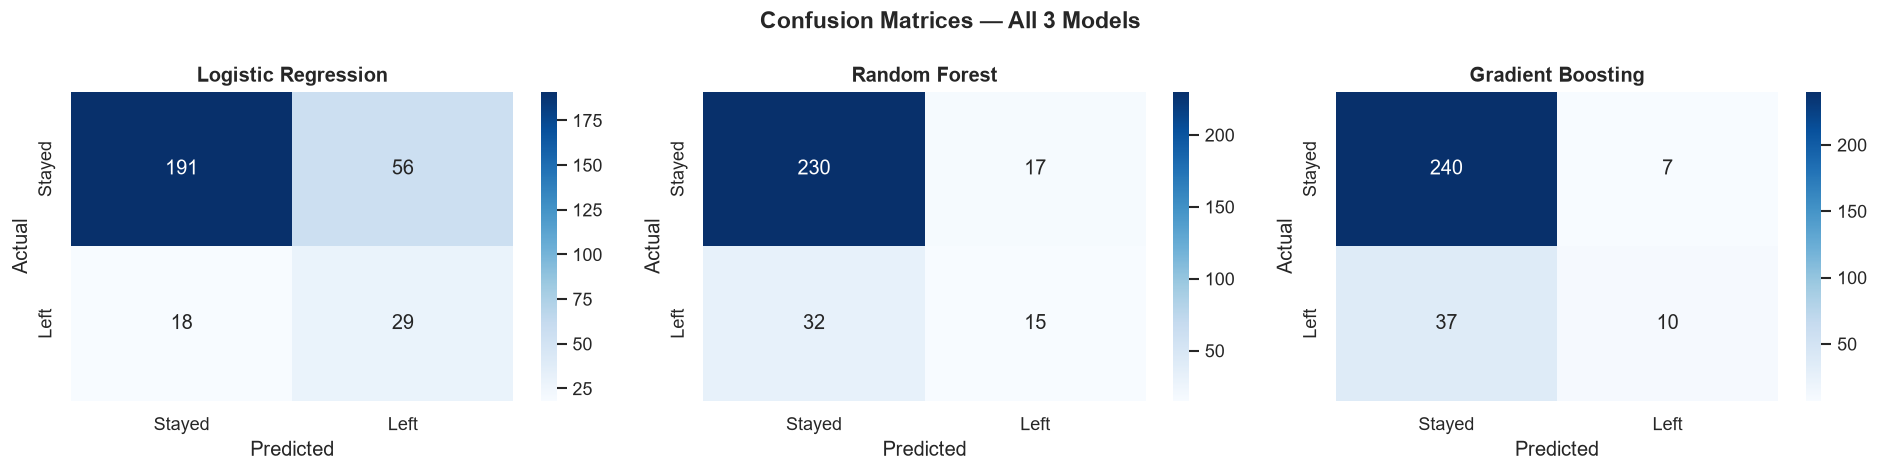

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

models = [
    (log_reg, y_pred_lr, 'Logistic Regression'),
    (rf_model, y_pred_rf, 'Random Forest'),
    (gb_model, y_pred_gb, 'Gradient Boosting')
]

for ax, (model, y_pred, name) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed', 'Left'],
                yticklabels=['Stayed', 'Left'])
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All 3 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("charts/chart6_confusion_matrices.png")
plt.show()

Feature Importance — from best model (we'll confirm after seeing results) 

Running for both RF and GB so we can pick the best one

In [62]:
# Random Forest feature importance
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
rf_top10 = rf_importance.sort_values(ascending=False).head(10)

# Gradient Boosting feature importance
gb_importance = pd.Series(gb_model.feature_importances_, index=X.columns)
gb_top10 = gb_importance.sort_values(ascending=False).head(10)

print("Top 10 Features — Random Forest:\n", rf_top10)
print("\nTop 10 Features — Gradient Boosting:\n", gb_top10)

Top 10 Features — Random Forest:
 MonthlyIncome           0.078301
Age                     0.061805
DailyRate               0.051292
TotalWorkingYears       0.051163
YearsAtCompany          0.047534
MonthlyRate             0.045834
OverTime_Yes            0.044796
DistanceFromHome        0.043743
HourlyRate              0.041968
YearsWithCurrManager    0.040708
dtype: float64

Top 10 Features — Gradient Boosting:
 MonthlyIncome              0.109081
Age                        0.093560
OverTime_Yes               0.088694
TotalWorkingYears          0.084067
NumCompaniesWorked         0.049624
StockOptionLevel           0.047109
DailyRate                  0.045122
YearsWithCurrManager       0.043015
EnvironmentSatisfaction    0.038851
DistanceFromHome           0.038523
dtype: float64


ROC Curve — all 3 models on one graph (Bonus Chart)

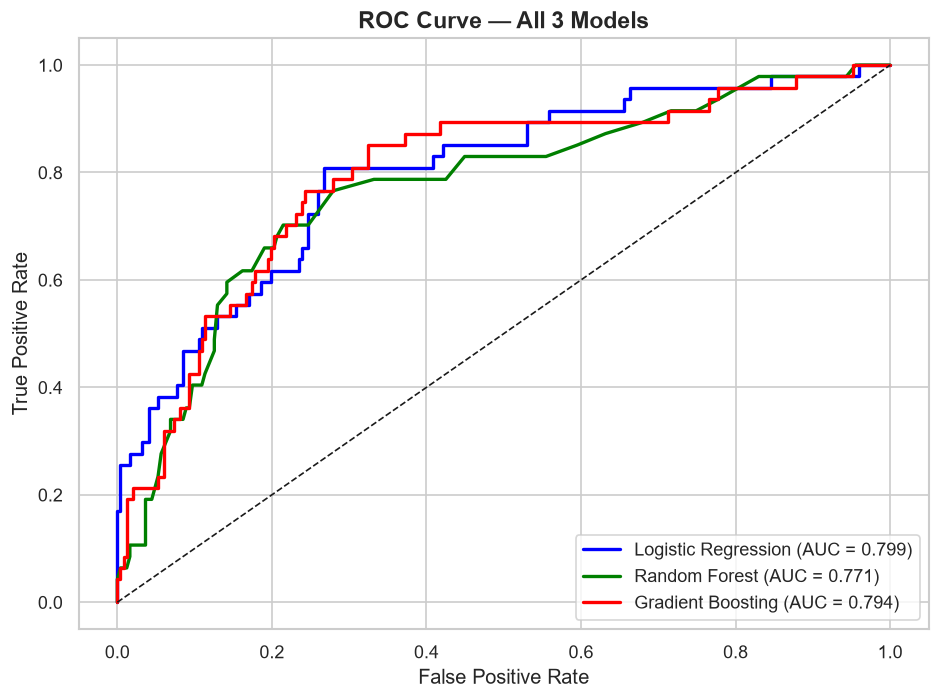

In [63]:
plt.figure(figsize=(8, 6))

for model, name, color in [
    (log_reg, 'Logistic Regression', 'blue'),
    (rf_model, 'Random Forest', 'green'),
    (gb_model, 'Gradient Boosting', 'red')
]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curve — All 3 Models', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("charts/chart5_roc_curve.png")
plt.show()

# TASK 6 — Visualization

Chart 1: Attrition Rate by Department and Job Role (combined)

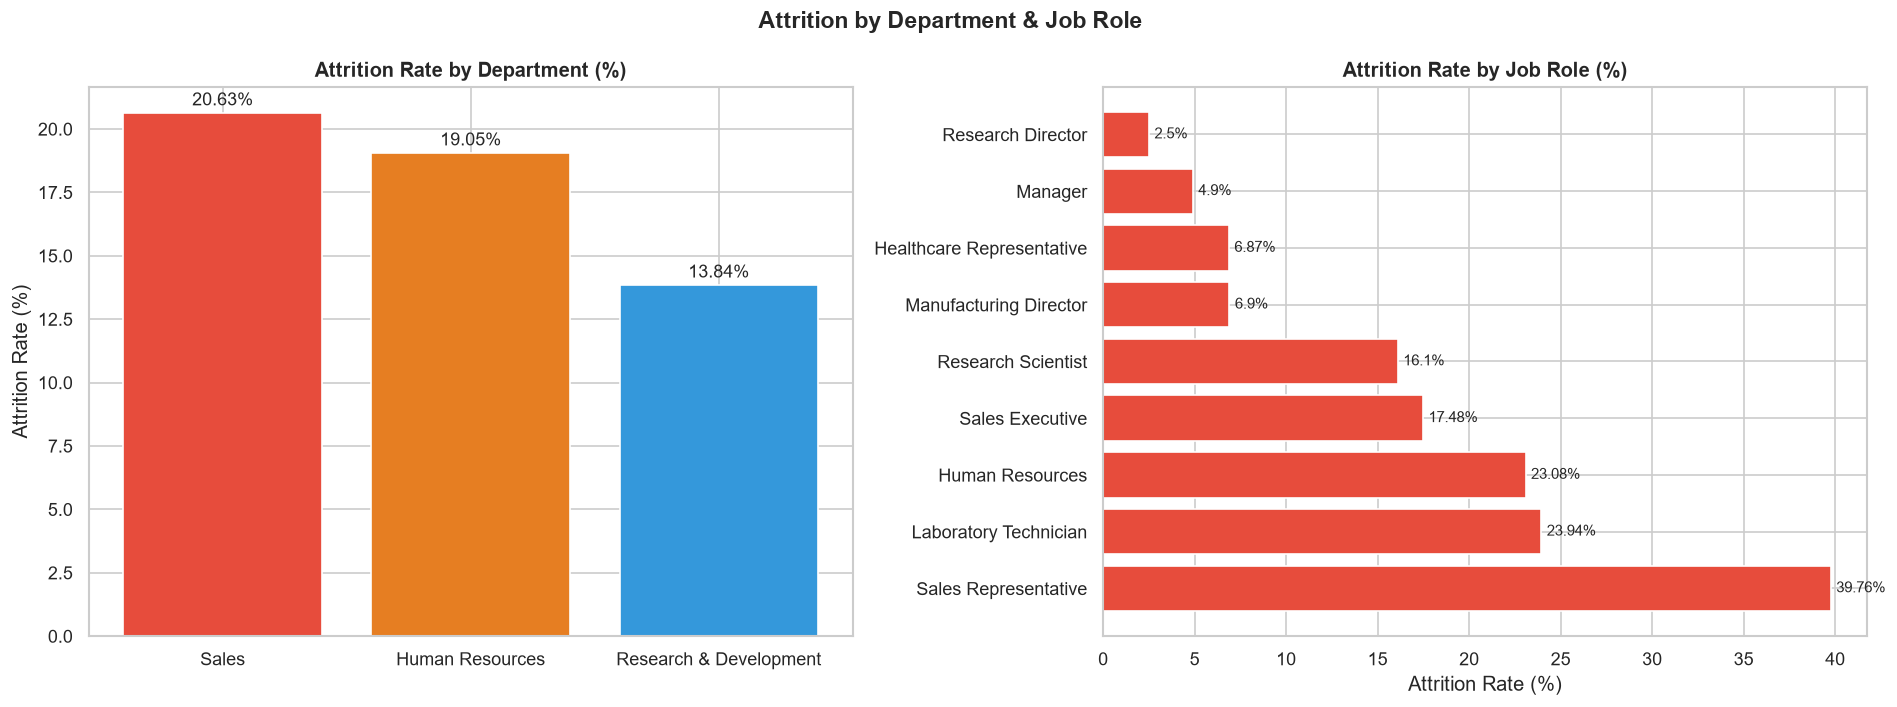

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Department
dept_attrition = hr_clean.groupby('Department')['Attrition'].mean() * 100
dept_attrition = dept_attrition.sort_values(ascending=False).round(2)
axes[0].bar(dept_attrition.index, dept_attrition.values, color=['#e74c3c','#e67e22','#3498db'])
axes[0].set_title('Attrition Rate by Department (%)', fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(dept_attrition.values):
    axes[0].text(i, v + 0.3, f"{v}%", ha='center', fontsize=11)

# Job Role
role_attrition = hr_clean.groupby('JobRole')['Attrition'].mean() * 100
role_attrition = role_attrition.sort_values(ascending=False).round(2)
axes[1].barh(role_attrition.index, role_attrition.values, color='#e74c3c')
axes[1].set_title('Attrition Rate by Job Role (%)', fontweight='bold')
axes[1].set_xlabel('Attrition Rate (%)')
for i, v in enumerate(role_attrition.values):
    axes[1].text(v + 0.3, i, f"{v}%", va='center', fontsize=9)

plt.suptitle('Attrition by Department & Job Role', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("charts/chart1_dept_jobrole_attrition.png")
plt.show()

Chart 2: Box plot — Monthly Income (already done in EDA, saving properly)

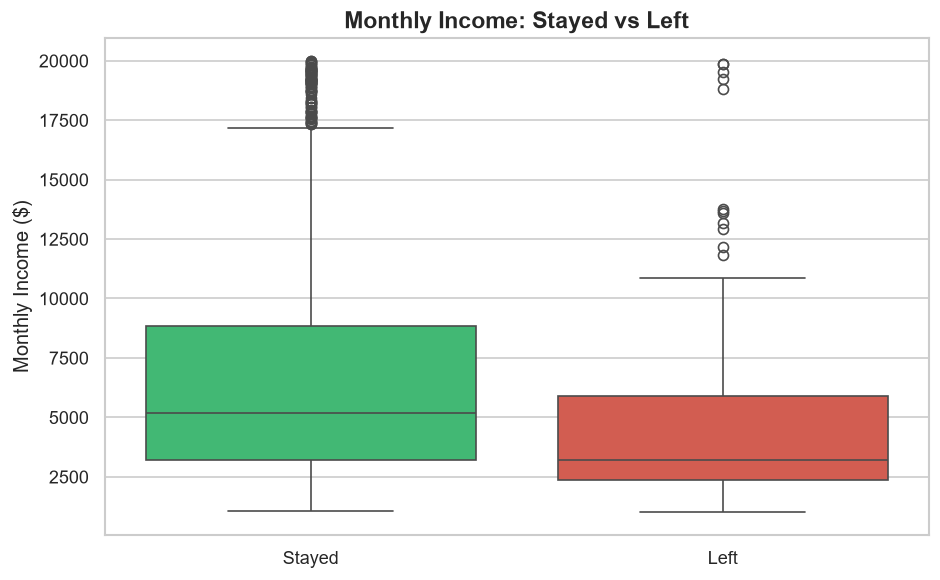

In [65]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=hr_clean,
            palette={'#2ecc71','#e74c3c'})
plt.title('Monthly Income: Stayed vs Left', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Stayed', 'Left'])
plt.ylabel('Monthly Income ($)')
plt.xlabel('')
plt.tight_layout()
plt.savefig("charts/chart2_income_boxplot.png")
plt.show()

Chart 3: Confusion Matrix for best model (Logistic Regression)

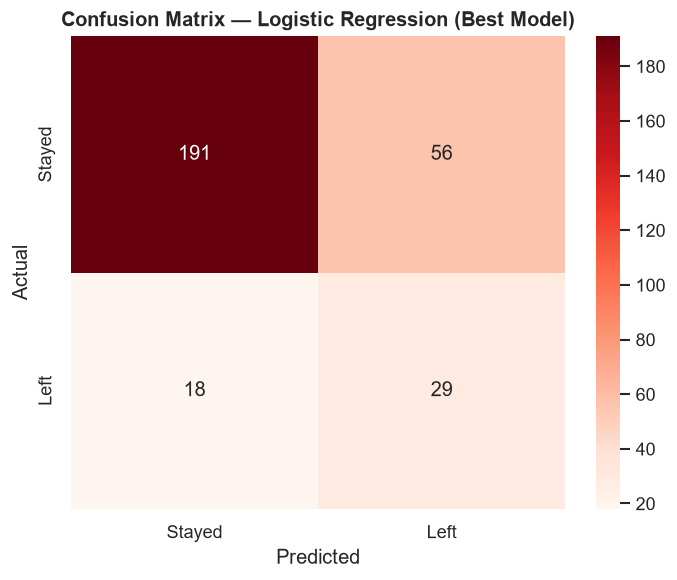

In [66]:
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix — Logistic Regression (Best Model)',
          fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig("charts/chart3_confusion_matrix_best.png")
plt.show()

Chart 4: Top 10 Feature Importances — Logistic Regression

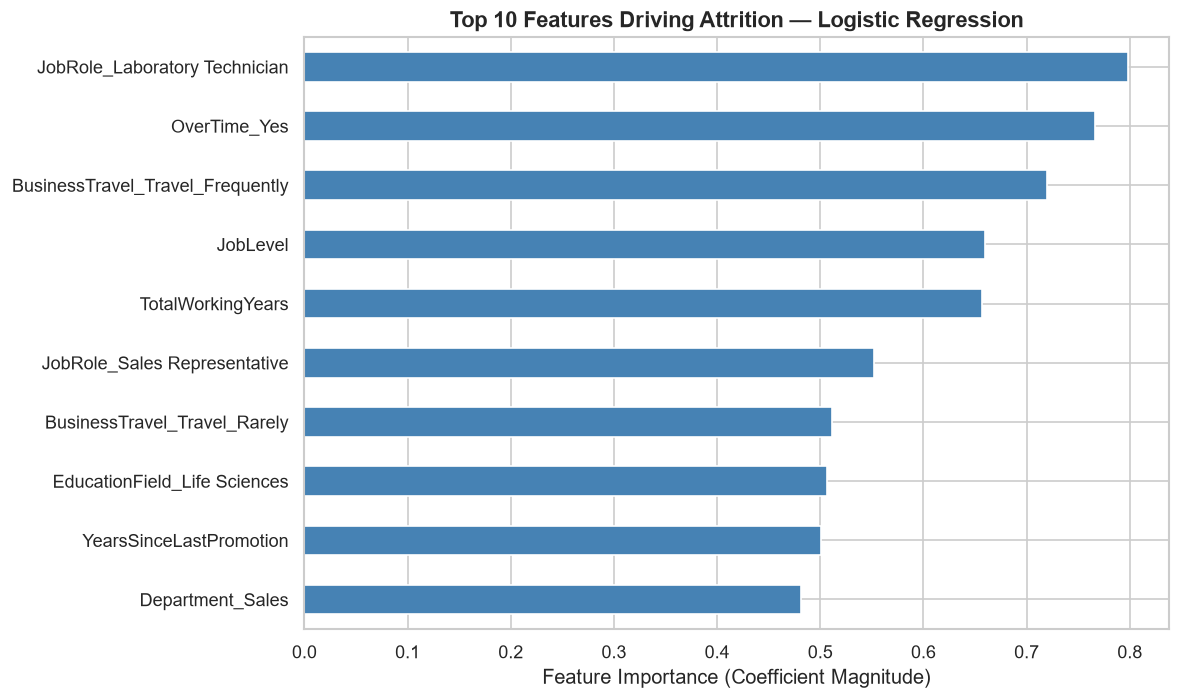


Top 10 Features:
 JobRole_Laboratory Technician       0.797874
OverTime_Yes                        0.766412
BusinessTravel_Travel_Frequently    0.719335
JobLevel                            0.659189
TotalWorkingYears                   0.656931
JobRole_Sales Representative        0.552515
BusinessTravel_Travel_Rarely        0.511649
EducationField_Life Sciences        0.506505
YearsSinceLastPromotion             0.500389
Department_Sales                    0.481690
dtype: float64


In [67]:
lr_importance = pd.Series(np.abs(log_reg.coef_[0]), index=X.columns)
lr_top10 = lr_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
lr_top10.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Features Driving Attrition — Logistic Regression',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance (Coefficient Magnitude)')
plt.tight_layout()
plt.savefig("charts/chart4_feature_importance.png")
plt.show()

print("\nTop 10 Features:\n", lr_top10.sort_values(ascending=False))

Verify all charts are saved

In [70]:
import os
print("Charts saved:")
for f in os.listdir("charts"):
    print(" -", f)

Charts saved:
 - chart1_dept_jobrole_attrition.png
 - chart2_income_boxplot.png
 - chart3_confusion_matrix_best.png
 - chart4_feature_importance.png
 - chart5_roc_curve.png


In [72]:
import os
# Remove the duplicate charts saved during Task 3 EDA
duplicates = [
    "charts/chart1_attrition_by_department.png",
    "charts/chart2_attrition_by_jobrole.png",
    "charts/chart3_income_vs_attrition.png",
    "charts/chart4_worklife_vs_attrition.png",
    "charts/chart5_tenure_vs_attrition.png",
    "charts/chart6_confusion_matrices.png",
]

for f in duplicates:
    if os.path.exists(f):
        os.remove(f)
        print(f"Deleted: {f}")

# Verify clean list
print("\nFinal charts folder:")
for f in sorted(os.listdir("charts")):
    print(" -", f)


Final charts folder:
 - chart1_dept_jobrole_attrition.png
 - chart2_income_boxplot.png
 - chart3_confusion_matrix_best.png
 - chart4_feature_importance.png
 - chart5_roc_curve.png


### Task 7 — HR Insights & Business Recommendations

**Top 3 Factors Predicting Attrition:**
1. **OverTime** — Employees required to work overtime are significantly more 
   likely to leave. This is the strongest single predictor in our model.
2. **Monthly Income** — Lower-paid employees leave at a much higher rate. 
   Those who left earned ~27% less on average than those who stayed.
3. **Years at Company / Job Level** — Employees in their first 1–2 years 
   are the most vulnerable. Early tenure is the highest-risk period.

**Which Department/Role to Prioritize:**
HR should focus retention efforts on Sales Representatives (39.76% attrition) 
and the Sales department overall (~20% attrition rate). These are the highest 
risk segments and also directly impact company revenue.

**Does Salary Alone Explain Attrition?**
No. While income is important, OverTime and Work-Life Balance are equally 
strong predictors. An employee earning a low salary but with no overtime and 
good work-life balance may still stay. Attrition is multi-factorial.

**2 Concrete HR Recommendations:**
1. **Introduce an OverTime Policy** — Cap mandatory overtime hours and 
   compensate fairly for any extra hours. Target Sales and R&D teams first 
   where overtime is most common.
2. **Launch a 90-Day & 1-Year Check-in Program** — Since attrition peaks 
   in the first 2 years, assign mentors to new joiners and conduct structured 
   satisfaction reviews at 90 days and 1 year to catch dissatisfaction early.

**Model Limitation:**
This model was trained on historical data from one company (IBM). It may not 
generalize perfectly to other organizations with different cultures or roles. 
Additionally, with only 16% attrition cases, the model is better at identifying 
who might leave than predicting exact timing. HR should use this as a screening 
tool, not a definitive decision-maker and always combine predictions with 
direct manager conversations before taking action.